## Install dependencies

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 8.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system

# Feature Engineering: Data Loading and Preprocessing

### load and expore data

In [ ]:
from datasets import load_dataset

dataset = load_dataset("lighteval/med_dialog", "icliniq")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['tgt', 'src', 'id'],
        num_rows: 24851
    })
    validation: Dataset({
        features: ['tgt', 'src', 'id'],
        num_rows: 3105
    })
    test: Dataset({
        features: ['tgt', 'src', 'id'],
        num_rows: 3108
    })
})


In [ ]:
# Print the first 20 'src' questions
for i in range(10):
    print(f"{i+1}. {dataset['train'][i]['tgt']}")

1. Please explain the poisonous effect of phenol ingestion
2. I have stomach pain and bloating after taking Augmentin 625. Why?
3. What medicine should I take for sore throat and stuffy nose?
4. My anti-TPO antibodies is 278 during my pregnancy. What does this indicate?
5. As semen smeared over vagina, I took an I-pill. Can I get pregnant?
6. Is it safe to take Risperidone for hallucination for a long time?
7. There is reduced mouth opening after wisdom tooth removal. Why?
8. My daughter's eye was poked with an umbrella. What to do?
9. What is the procedure to replace a small size condyle?
10. My sperm analysis shows low motility grade A. Am I infertile?


In [ ]:
# Shuffle the dataset (seed ensures consistent shuffling)
# dataset = dataset['train'].shuffle(seed=42)
# dataset = dataset.select(range(81000))

### transform data and columns extraction

In [ ]:
# Split the existing "src" into "patient_query" and "doctor_response"
def split_src_into_query_response(example):
    parts = example["src"].split("Doctor:")
    patient_query = parts[0].strip()
    doctor_response = parts[1].strip() if len(parts) > 1 else ""

    # Update the dataset
    example["src"] = patient_query
    example["tgt"] = doctor_response
    return example

# Apply the transformation to all splits
dataset = dataset.map(split_src_into_query_response)
dataset = dataset.rename_column("src", "patient_query")
dataset = dataset.rename_column("tgt", "doctor_response")
dataset = dataset.rename_column("id", "conversation_id")

# dataset[10]
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['doctor_response', 'patient_query', 'conversation_id'],
        num_rows: 24851
    })
    validation: Dataset({
        features: ['doctor_response', 'patient_query', 'conversation_id'],
        num_rows: 3105
    })
    test: Dataset({
        features: ['doctor_response', 'patient_query', 'conversation_id'],
        num_rows: 3108
    })
})


In [ ]:
dataset['train'][39]

{'doctor_response': "Hi. One's skin color has 2 components. First one is genetic, which cannot be changed. Every skin color is beautiful in its own way and we should learn to love our skin color and augment it and not hide or lighten it. The second component is acquired, which is due to the influence of environment, sunlight, hormones, aging, etc. We can only target the acquired component of fair skin color while attempting lightening procedures. I suggest you antioxidant capsules like capsule Antoxid HC (Beta-carotene) and apply sunscreen lotion Lashield gel at 8 AM and 12 PM. Also, you can apply Glyaha koj lotion (Hydroquinone) at night time. Start with an alternate night application initialy as it may irritate your skin a bit and after a week or so, shift to daily night application. Consult your specialist doctor, discuss with him or her and take the treatment with consent. You can go for chemical peeling or microdermabrasion from your dermatologist which will help in exfoliating an

### data cleaning & Normalisation

In [ ]:
import re
import pandas as pd

# Define a clean_text function specific for clinical chatbot data
def clean_text(text):
    if pd.isna(text):
        return text

    # Trim whitespace and normalize text lengths
    text = text.strip()

    # Convert multiple spaces to a single space
    text = re.sub(r'\s+', ' ', text)

    # Remove email patterns
    text = re.sub(r'\S+@\S+\.\S+', '', text)

    # Remove website references
    text = re.sub(r'\b(?:https?://|www\.)\S+\b', '', text)

    # Remove mentions of "contact", "website", "@" as these are not useful in clinical responses
    text = re.sub(r'\b(contact|website|@)\b', '', text)

    # Remove patient/doctor role mentions, but keep relevant terms (e.g., diagnosis, symptoms)
    text = re.sub(r'\b(patient|doctor):?\b', '', text)

    # Remove any sensitive information (e.g., medical ID, address, etc.) - based on regex patterns
    # You may choose to add more rules here if you have specific sensitive data
    text = re.sub(r'\b\d{3}-\d{2}-\d{4}\b', '', text)  # Remove social security numbers or other formats if needed

    # Remove special characters except for necessary punctuation (e.g., commas, periods)
    text = re.sub(r'[^a-zA-Z0-9\s,.\-?!:;()&/]', '', text)

    # Optional: Keep punctuation (comma, period, question mark) but normalize spacing
    text = re.sub(r'\s([.,!?;])', r'\1', text)  # Remove extra space before punctuation

    # Optional: Replace some abbreviations with full forms, if needed (example: "Dr." -> "Doctor")
    text = text.replace('Dr.', 'Doctor')

    # Remove emails
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

    # Remove phone numbers (formats: 123-456-7890 or 1234567890)
    text = re.sub(r'\b\d{10}\b|\d{3}[-.\s]??\d{3}[-.\s]??\d{4}', '', text)

    # Remove professional titles
    text = re.sub(r"\bdr\.\s*\w+", "", text, flags=re.IGNORECASE)

    # Remove contact prompts
    text = re.sub(r'(?:please\s+)?(?:consult|contact|visit|reach out to|see|meet)\s+(?:your|a|the)?\s*(?:doctor|physician|specialist|dr\.?|clinician|hospital)\b', '', text, flags=re.IGNORECASE)

    # Medical terminology corrections
    replacements = {
        r"\bssri\b": "SSRI",
        r"\bsle\b": "systemic lupus erythematosus",
        r"\bturp\b": "transurethral resection of the prostate",
        r"\bmri\b": "MRI",
        r"\bclt\b": "cystolitholapaxy",
        r"\bafib\b": "atrial fibrillation",
        r"\banyboxy\b": "anybody",
        r"\bbcoz\b": "because",
        r"\btp\b": "treatment plan"
    }

    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text)

    # Fix spacing around punctuation
    text = re.sub(r'([.,!?()])([^\s])', r'\1 \2', text)
    text = re.sub(r'([^\s])([.,!?()])', r'\1 \2', text)

    # Remove non-informative short responses (too short to provide context)
    # For example, if you consider less than 3 words as unhelpful, you can filter those out
    if len(text.split()) < 3:
        return None  # Consider filtering out short responses if required

    return text


# Convert to pandas
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()
validation_df = dataset['validation'].to_pandas()

# Apply cleaning function to specific columns
train_df['doctor_response'] = train_df['doctor_response'].apply(clean_text)
train_df['patient_query'] = train_df['patient_query'].apply(clean_text)

test_df['doctor_response'] = test_df['doctor_response'].apply(clean_text)
test_df['patient_query'] = test_df['patient_query'].apply(clean_text)

validation_df['doctor_response'] = validation_df['doctor_response'].apply(clean_text)
validation_df['patient_query'] = validation_df['patient_query'].apply(clean_text)

In [ ]:
train_df.head()

,doctor_response,patient_query,conversation_id
0,Hi . I want to assure you not to worry as ever...,"Patient: Hello , My friend aged 30 had two dro...",12856
1,Hello . I welcome you to icliniq . Well it is ...,Patient: Age - 33 years Height - 164 cms Weigh...,1000
2,Hello . You seem to be suffering from an acute...,"Patient: Hi , I have a sore throat and stuffy ...",17952
3,Hello . Elevated levels of anti-TPO antibodies...,"Patient: Hello , I am 28 years old . I got pre...",8452
4,Hello . For further doubts consult an obstetri...,"Patient: Hello , Semen smeared over vagina wit...",19911


In [ ]:
train_df.iloc[39,0]

'Hi . Ones skin color has 2 components . First one is genetic , which cannot be changed . Every skin color is beautiful in its own way and we should learn to love our skin color and augment it and not hide or lighten it . The second component is acquired , which is due to the influence of environment , sunlight , hormones , aging , etc . We can only target the acquired component of fair skin color while attempting lightening procedures . I suggest you antioxidant capsules like capsule Antoxid HC ( Beta-carotene ) and apply sunscreen lotion Lashield gel at 8 AM and 12 PM . Also , you can apply Glyaha koj lotion ( Hydroquinone ) at night time . Start with an alternate night application initialy as it may irritate your skin a bit and after a week or so , shift to daily night application . , discuss with him or her and take the treatment with consent . You can go for chemical peeling or microdermabrasion from your dermatologist which will help in exfoliating and give you a clearer skin ton

In [ ]:
def reclean_doctor_response(text):
    # Remove email patterns
    text = re.sub(r'\S+@\S+\.\S+', '', text)

    # Remove website references
    text = re.sub(r'\b(?:https?://|www\.)\S+\b', '', text)

    # Remove greetings/thanks patterns
    text = re.sub(r'(?i)\b(?:dear|welcome|thanks? you?|regards|cheers|wish(?:ing)?)\b[,.!]*', '', text)

    # Remove doctor self-references
    text = re.sub(r'\b(?:I|me|my|doctor|Dr\.? \w+)\b', '', text, flags=re.IGNORECASE)

    # Remove contact prompts
    text = re.sub(r'(?:please\s+)?(?:consult|contact|visit|reach out to|see|meet)\s+(?:your|a|the)?\s*(?:doctor|physician|specialist|dr\.?|clinician|hospital)\b', '', text, flags=re.IGNORECASE)

    # Clean special characters and formatting artifacts
    text = re.sub(r'[^a-zA-Z0-9\s.,?!-]', '', text)  # Remove non-standard characters
    text = re.sub(r'\s+', ' ', text).strip()  # Fix whitespace

    # Remove residual patterns
    text = re.sub(r'\b(?:answered? query|healthcare magic|hcmi|hcm|service reviewed|welcomequesuon)\b', '', text, flags=re.IGNORECASE)

    return text.lower() if text else text


train_df["doctor_response"] = train_df["doctor_response"].apply(reclean_doctor_response)
test_df["doctor_response"] = test_df["doctor_response"].apply(reclean_doctor_response)

In [ ]:
print(train_df.shape, test_df.shape)
train_df.head()

In [ ]:
train_df.iloc[39,0]

In [ ]:
train_df.isnull().sum()

,0
doctor_response,70
patient_query,0
conversation_id,0


### Quality Filtering:

In [ ]:
# Define the filter function
def quality_filter(response):
    # Check for prohibited phrases
    if any(phrase in response for phrase in ['contact', 'website', '@']):
        return False
    return True

# Filter the DataFrame
tain_df = train_df[train_df["doctor_response"].apply(quality_filter)]
test_df = test_df[test_df["doctor_response"].apply(quality_filter)]

train_df.shape, test_df.shape

TypeError: argument of type 'NoneType' is not iterable

In [ ]:
train_df

In [ ]:
# duplicate_rows = test_df[test_df.duplicated(subset=["patient_query", "doctor_response"], keep=False)]
# print(duplicate_rows.shape)
# duplicate_rows = train_df[train_df.duplicated(subset=["patient_query", "doctor_response"], keep=False)]
# print(duplicate_rows.shape)
# duplicate_rows.head(5)

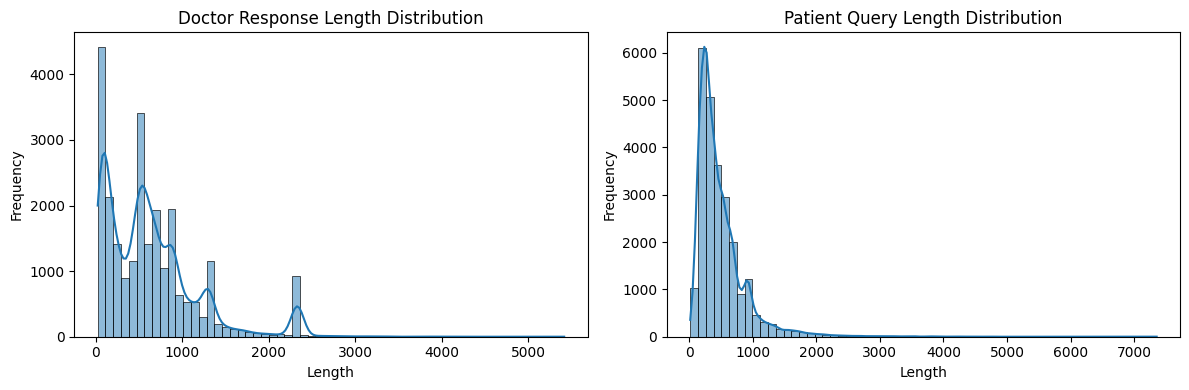

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add text length columns
train_df['doctor_response_length'] = train_df['doctor_response'].str.len()
train_df['patient_query_length'] = train_df['patient_query'].str.len()

plt.figure(figsize=(12, 4))

# Doctor response length distribution
plt.subplot(1, 2, 1)
sns.histplot(train_df['doctor_response_length'], bins=60, kde=True)
plt.title("Doctor Response Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

# Patient query length distribution
plt.subplot(1, 2, 2)
sns.histplot(train_df['patient_query_length'], bins=60, kde=True)
plt.title("Patient Query Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
train_df[['patient_query_length', 'doctor_response_length']].describe()

,patient_query_length,doctor_response_length
count,24851.000000,24781.000000
mean,493.412297,638.491949
std,416.051548,548.289483
min,16.000000,25.000000
25%,248.000000,178.000000
50%,389.000000,557.000000
75%,616.000000,893.000000
max,7354.000000,5417.000000


In [ ]:
train_df[(train_df['patient_query_length'] > 2000) | (train_df['doctor_response_length'] > 2000)] .shape

(1376, 5)

In [ ]:
# Function to clean and filter the DataFrame
def clean_and_filter(df, min_text_length=10, max_text_length = 2000):
    # Drop rows with missing or empty text fields
    df.dropna(subset=["patient_query", "doctor_response"], inplace=True)

    # Trim whitespace and normalize text lengths
    df["patient_query"] = df["patient_query"].str.strip()
    df["doctor_response"] = df["doctor_response"].str.strip()

    # Ensure lengths are computed
    df["patient_query_length"] = df["patient_query"].str.len()
    df["doctor_response_length"] = df["doctor_response"].str.len()

    # Apply the filtering conditions
    df = df[
        (df["doctor_response_length"] >= min_text_length) &
        (df["patient_query_length"] >= min_text_length) &
        (df["doctor_response_length"] <= max_text_length) &
        (df["patient_query_length"] <= max_text_length)
    ]
    return df

# Apply the cleaning and filtering function to both datasets
train_df = clean_and_filter(train_df)
test_df = clean_and_filter(test_df)
validation_df = clean_and_filter(validation_df)

print("Filtered train_df shape:", train_df.shape)
print("Filtered test_df shape:", test_df.shape)
print("Filtered validation_df shape:", validation_df.shape)

Filtered train_df shape: (23408, 5)
Filtered test_df shape: (2936, 5)
Filtered validation_df shape: (2914, 5)


In [ ]:
# Define the filter function
def quality_filter(response):
    # Check for prohibited phrases
    if any(phrase in response for phrase in ['contact', 'website', '@']):
        return False
    return True

# Filter the DataFrame
tain_df = train_df[train_df["doctor_response"].apply(quality_filter)]
test_df = test_df[test_df["doctor_response"].apply(quality_filter)]
validation_df = validation_df[validation_df["doctor_response"].apply(quality_filter)]
train_df.shape, test_df.shape, validation_df.shape

((23408, 5), (2931, 5), (2911, 5))

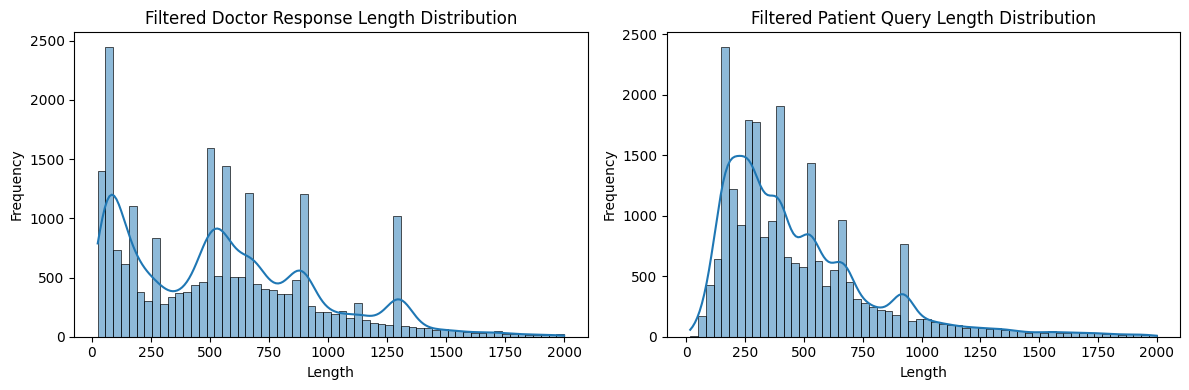

In [ ]:
plt.figure(figsize=(12, 4))

# Doctor response length distribution
plt.subplot(1, 2, 1)
sns.histplot(train_df['doctor_response_length'], bins=60, kde=True)
plt.title("Filtered Doctor Response Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

# Patient query length distribution
plt.subplot(1, 2, 2)
sns.histplot(train_df['patient_query_length'], bins=60, kde=True)
plt.title("Filtered Patient Query Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Data Analysis

In [ ]:
df = train_df

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23408 entries, 0 to 24850
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   doctor_response         23408 non-null  object
 1   patient_query           23408 non-null  object
 2   conversation_id         23408 non-null  int64 
 3   doctor_response_length  23408 non-null  int64 
 4   patient_query_length    23408 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,conversation_id,doctor_response_length,patient_query_length
count,23408.000000,23408.000000,23408.000000
mean,15440.903922,555.943267,472.452879
std,8984.824907,407.260563,324.342246
min,0.000000,25.000000,16.000000
25%,7674.750000,162.000000,248.000000
50%,15273.500000,521.000000,389.000000
75%,23214.750000,823.250000,614.000000
max,31063.000000,2000.000000,2000.000000


In [ ]:
# Check for missing values
df.isnull().sum()

,0
doctor_response,0
patient_query,0
conversation_id,0
doctor_response_length,0
patient_query_length,0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


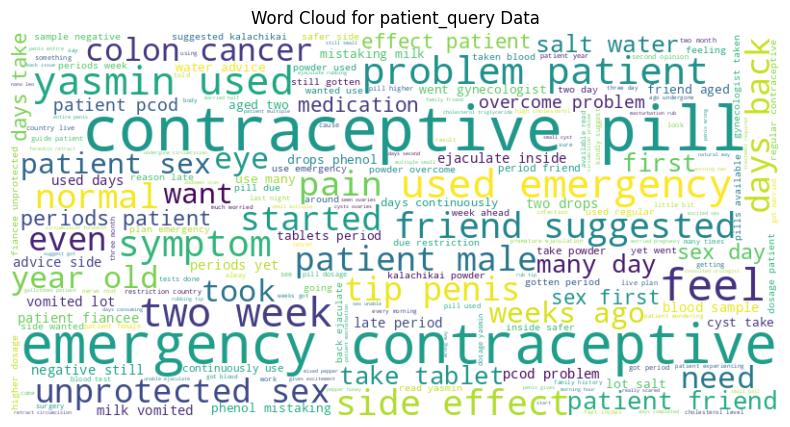

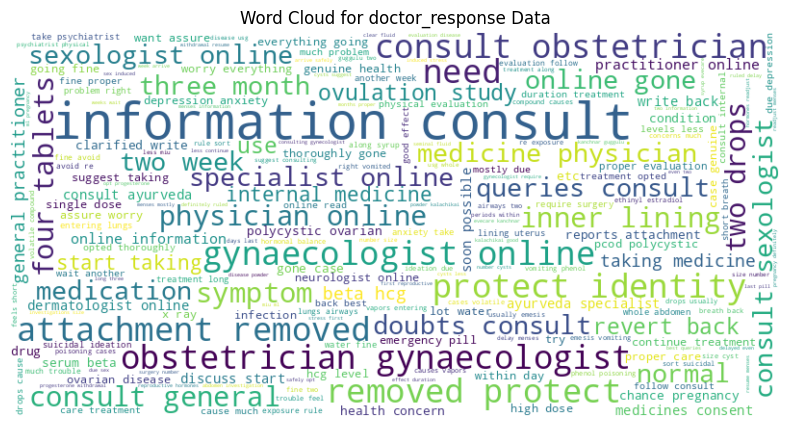

In [ ]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download stopwords (if not already downloaded)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Custom stopwords from your unwanted words list
custom_stopwords = set([
    'query', 'test', 'question', 'service', 'answer', 'thanks', 'reviewed', 'healthcare', 'welcome', 'help', 'magic',
    'dear', 'thanks', 'please', 'thing', 'area', 'make','may', 'said', 'hello', 'wish', 'function', 'mrght', 'hello',
    'hi', 'years', 'year', 'old', 'one', 'think', 'know', 'let', 'ask', 'hope', 'understand', 'well', 'seem', 'time'
])

# Function to clean and preprocess text
def preprocess_text(text_series):
    all_words = ' '.join(text_series)
    # Split and filter stopwords
    filtered_words = [word.lower() for word in all_words.split()
                       if word.lower() not in stop_words and
                       word.lower() not in custom_stopwords and
                       len(word) > 2]
    return ' '.join(filtered_words)

# Most common words in patient queries and doctor responses
patient_common_words = preprocess_text(df['patient_query'])
doctor_common_words = preprocess_text(df['doctor_response'])

def plot_wordcloud(text_data, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=200,
        colormap='viridis',
        contour_width=1,
        contour_color='steelblue'
    ).generate(text_data)

    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Hide axes
    plt.show()

# Generate word clouds for both datasets
plot_wordcloud(patient_common_words, "Word Cloud for patient_query Data")
plot_wordcloud(doctor_common_words, "Word Cloud for doctor_response Data")


In [ ]:
# Count the number of unique conversation IDs
print(f"Number of unique conversations in train split: {df['conversation_id'].nunique()}")

# Average length of patient queries and doctor responses
print(f"Average patient query length: {df['patient_query_length'].mean():.2f}")
print(f"Average doctor response length: {df['doctor_response_length'].mean():.2f}")

Number of unique conversations in train split: 23408
Average patient query length: 472.45
Average doctor response length: 555.94


### Classify answers

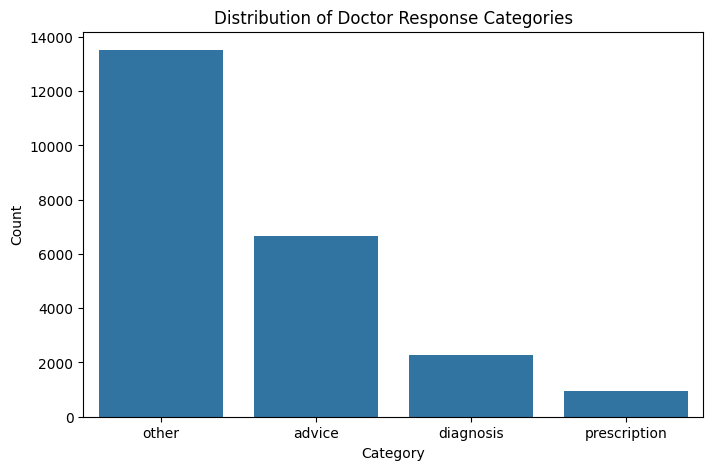

In [ ]:
# Define keywords for different response types
response_categories = {
    "advice": ["advise", "suggest", "recommend"],
    "diagnosis": ["diagnose", "condition", "symptom"],
    "prescription": ["prescribe", "medication", "dose"]
}

# Categorize doctor responses
def categorize_response(response):
    for category, keywords in response_categories.items():
        if any(keyword in response.lower() for keyword in keywords):
            return category
    return "other"

df['response_category'] = df['doctor_response'].apply(categorize_response)

# Plot response categories
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='response_category', order=df['response_category'].value_counts().index)
plt.title("Distribution of Doctor Response Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

# Export to CSV
train_df[["patient_query", "doctor_response"]].to_csv("/content/drive/MyDrive/Medical Chatbot/data/processed/meddialog_cliniq_trian.csv", index=False, encoding='utf-8')
test_df[["patient_query", "doctor_response"]].to_csv("/content/drive/MyDrive/Medical Chatbot/data/processed/meddialog_cliniq_test.csv", index=False, encoding='utf-8')
validation_df[["patient_query", "doctor_response"]].to_csv("/content/drive/MyDrive/Medical Chatbot/data/processed/meddialog_cliniq_validation.csv", index=False, encoding='utf-8')

In [ ]:
from sklearn.model_selection import train_test_split

# Keep only the relevant columns
df = df[["patient_query", "doctor_response"]]

# Split the dataset: 80% for training and 20% for testing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Check the sizes of splits
print(f"Training data size: {train_df.shape[0]}")
print(f"Testing data size: {test_df.shape[0]}")

# Export to CSV files
train_df.to_csv("/content/drive/MyDrive/Medical Chatbot/data/processed/cleaned_meddialog_train_sample.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/Medical Chatbot/data/processed/cleaned_meddialog_test_sample.csv", index=False)

print("CSV files exported successfully!")

Training data size: 54143
Testing data size: 13536
CSV files exported successfully!


#### memory cleaning

In [ ]:
# Gestion de memoire
del duplicate_rows, custom_stopwords, doctor_common_words, patient_common_words, stop_words
del dataset, df, train_df, test_df, stopwords, response_categories

import torch
torch.cuda.empty_cache()
import gc
gc.collect()

35412

---

# Model Building

### Load the Dataset - Tokenizer - Model

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
shared_folder_path = "/content/drive/MyDrive/Medical Chatbot"  # Adjust to the folder name
os.chdir(shared_folder_path)
print(f"Current Directory: {os.getcwd()}")

Current Directory: /content/drive/.shortcut-targets-by-id/1_olpwMEoHGgtJw9Uxb1nJganD7MsSkLZ/Medical Chatbot


In [32]:
import pandas as pd
from datasets import Dataset

# Load the dataset
train_data = pd.read_csv("/content/drive/MyDrive/Medical Chatbot/data/processed/meddialog_cliniq_trian.csv")
test_data = pd.read_csv("/content/drive/MyDrive/Medical Chatbot/data/processed/meddialog_cliniq_test.csv")
validation_data = pd.read_csv("/content/drive/MyDrive/Medical Chatbot/data/processed/meddialog_cliniq_validation.csv")
# Prepare the dataset for Hugging Face format
train_data = Dataset.from_pandas(train_data)
test_data = Dataset.from_pandas(test_data)
validation_data = Dataset.from_pandas(validation_data)

In [16]:
from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments
model_name = "t5-small"
# model_name = "google-t5/t5-small"

# Load tokenizer and model
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

###  Tokenizaation

In [35]:
def preprocess_function(examples):
    inputs = examples["patient_query"]
    targets = examples["doctor_response"]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length")

    # Tokenize targets
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=512, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Preprocess dataset
train_data = train_data.map(preprocess_function, batched=True)
test_data = test_data.map(preprocess_function, batched=True)
validation_data = validation_data.map(preprocess_function, batched=True)

Map:   0%|          | 0/23408 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3953: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/2931 [00:00<?, ? examples/s]

Map:   0%|          | 0/2911 [00:00<?, ? examples/s]

### Fine-Tuning with Trainer

In [17]:
# Define Training Arguments
training_args = TrainingArguments(
    output_dir="./results",          # output directory for model checkpoints
    evaluation_strategy="epoch",     # evaluation strategy (check the model every epoch)
    learning_rate=2e-5,              # learning rate
    per_device_train_batch_size=16,   # batch size for training
    per_device_eval_batch_size=16,    # batch size for evaluation
    num_train_epochs=3,              # number of training epochs
    weight_decay=0.01,               # weight decay
    save_strategy="epoch",           # save model after every epoch
    logging_dir='./logs',            # directory for storing logs
    logging_steps=500,               # Log every 500 steps
    save_steps=500,                  # Save model every 500 steps
    load_best_model_at_end=True,     # Load the best model at the end of training
)

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=validation_data,
    tokenizer=tokenizer,
)

# Start training the model
trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-17-b22be1948f25>:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abdelghafourbamoula (abdelghafourbamoula-mohammed-v-university-in-rabat) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch,Training Loss,Validation Loss
1,0.926200,0.705084
2,0.776100,0.625517


OutOfMemoryError: CUDA out of memory. Tried to allocate 1004.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 818.12 MiB is free. Process 10313 has 13.94 GiB memory in use. Of the allocated memory 13.54 GiB is allocated by PyTorch, and 278.05 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

- API key : 95089631a3ae1baed670bab76c375a96810a3450

### Evaluation

In [19]:
# Evaluate the model on the test set after training
trainer.evaluate(test_data)

Epoch,Training Loss,Validation Loss
1,0.926200,0.705084
2,0.729000,0.638972


{'eval_loss': 0.6389721035957336}

### Save the Model

In [18]:
model.save_pretrained("/content/drive/MyDrive/Medical Chatbot/model/t5-small-model")
tokenizer.save_pretrained("/content/drive/MyDrive/Medical Chatbot/model/t5-small-model")
print("Model and tokenizer saved.")

Model and tokenizer saved.


In [20]:
import os

# Path to the logging directory
log_dir = './logs'

# Read the logs (this assumes you're logging in a CSV-like format)
log_files = os.listdir(log_dir)
log_file = [file for file in log_files if file.endswith(".csv")][0]

# Load the logs into a pandas DataFrame
import pandas as pd
log_df = pd.read_csv(os.path.join(log_dir, log_file))

# Plot the training loss
plt.plot(log_df['step'], log_df['loss'], label='Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.show()


IndexError: list index out of range

In [21]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    # Get the predictions and the labels
    preds = pred.predictions.argmax(axis=-1)
    labels = pred.label_ids

    # Calculate accuracy and F1 score
    accuracy = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')  # For multi-class use 'weighted'

    return {"accuracy": accuracy, "f1": f1}


In [23]:
# Make predictions on the test set
test_results = trainer.predict(test_data)

# Compute metrics (accuracy, F1)
metrics = compute_metrics(test_results)
print(metrics)


Epoch,Training Loss,Validation Loss
1,0.926200,0.705084
2,0.729000,0.638972


OutOfMemoryError: CUDA out of memory. Tried to allocate 1004.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 818.12 MiB is free. Process 10313 has 13.94 GiB memory in use. Of the allocated memory 13.58 GiB is allocated by PyTorch, and 229.74 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### Evaluation

BLEU score: {'bleu': 0.4224381807525124, 'precisions': [0.9166666666666666, 0.5454545454545454, 0.4, 0.2222222222222222], 'brevity_penalty': 0.9200444146293233, 'length_ratio': 0.9230769230769231, 'translation_length': 12, 'reference_length': 13}
ROUGE score: {'rouge1': 0.8695652173913043, 'rouge2': 0.5714285714285713, 'rougeL': 0.7826086956521738, 'rougeLsum': 0.7826086956521738}

In [ ]:
! pip install evaluate rouge_score

In [37]:
import evaluate

# Load the BLEU and ROUGE metrics
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

# Example predictions and references (you would use your actual test set here)
predictions = ["The patient should follow a balanced diet and take prescribed medications."]
references = [["The patient should follow a healthy diet and take the medications prescribed."]]

# Compute BLEU score
bleu_results = bleu_metric.compute(predictions=predictions, references=references)
print(f"BLEU score: {bleu_results}")

# Compute ROUGE score
rouge_results = rouge_metric.compute(predictions=predictions, references=references)
print(f"ROUGE score: {rouge_results}")


BLEU score: {'bleu': 0.4224381807525124, 'precisions': [0.9166666666666666, 0.5454545454545454, 0.4, 0.2222222222222222], 'brevity_penalty': 0.9200444146293233, 'length_ratio': 0.9230769230769231, 'translation_length': 12, 'reference_length': 13}
ROUGE score: {'rouge1': 0.8695652173913043, 'rouge2': 0.5714285714285713, 'rougeL': 0.7826086956521738, 'rougeLsum': 0.7826086956521738}


In [38]:
meteor_metric = evaluate.load("meteor")
meteor_results = meteor_metric.compute(predictions=predictions, references=references)
print(f"METEOR score: {meteor_results}")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


METEOR score: {'meteor': 0.7835223268627074}


METEOR score: {'meteor': 0.7835223268627074}

BLEU score: {'bleu': 0.4224381807525124, 'precisions': [0.9166666666666666, 0.5454545454545454, 0.4, 0.2222222222222222], 'brevity_penalty': 0.9200444146293233, 'length_ratio': 0.9230769230769231, 'translation_length': 12, 'reference_length': 13}
ROUGE score: {'rouge1': 0.8695652173913043, 'rouge2': 0.5714285714285713, 'rougeL': 0.7826086956521738, 'rougeLsum': 0.7826086956521738}

### Inference Example

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# Path where the model is saved
model_path = "/content/drive/MyDrive/Medical Chatbot/model/t5_meddialog_model"  # Update this to the actual path of your saved model

# Check if GPU is available, else use CPU
# device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the tokenizer and model from the saved path
tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=True)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# Move model to the selected device (GPU or CPU)
# model.to(device)

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


In [ ]:
import torch
device = "cpu"#cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

In [56]:
def generate_response(patient_query):
    input_text =  patient_query
    input_ids = tokenizer(input_text, return_tensors="pt", padding=True, truncation=True).input_ids

    # Generating with adjusted parameters
    output_ids = model.generate(input_ids,  max_length=1024,  num_beams=5,no_repeat_ngram_size=2, top_k=10, do_sample=True)

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [72]:
def generate_response(patient_query):
    # input_text = "hi doctor, " + patient_query.strip().lower()
    # input_text = "you are a doctor, this is you patient case : "# + patient_query.strip().lower()
    input_text = "I am your patient, I will explain to you my case: " + patient_query
    input_ids = tokenizer(input_text, return_tensors="pt", padding=True, truncation=True).input_ids

    # Generating with adjusted parameters
    output_ids = model.generate(
        input_ids,
        max_length=512,        # Limit response length
        top_k=30,             # Control randomness
        top_p=0.95,           # Control diversity
        # num_beams=3,          # Beam search for better output
        temperature=0.55,      # Reduce randomness
        no_repeat_ngram_size=2,  # Avoid repetitive text
        do_sample=True
    )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [73]:
from IPython.display import display, Markdown
query = """I’m a 30-year-old woman who’s been having a mild headache for the last 3 days.
Should I be concerned or is this just a regular tension headache?"""
display(Markdown(generate_response(query)))

I have gone through your case with a clear and clear indication of your condition and you may be worried about it. If you have neurologist, then you might be wondering if it is causing recurrent tension, or you should have to worry about the cause of tension headaches. For further information consult etiologist online --

In [74]:
from IPython.display import display, Markdown

queries = {
    # Short query with necessary info
    'small': "I've been coughing without producing any phlegm or mucus. Sometimes I taste blood but none comes up. Can you help me figure out what might be going on?",

    # Medium-length query with necessary details
    'medium': "I'm experiencing chest discomfort and coughing without any mucus. Occasionally, there's a taste of blood, but no blood has come out. I don't have any serious medical conditions, but I have had bacterial, fungal, and viral infections in the past. What could this be?",

    # Long and detailed query
    'long': "Hi, good morning. I’ve been feeling discomfort in my chest which triggers coughing, but there’s no phlegm or mucus coming up. Occasionally, I have a taste of blood in my mouth, but none actually comes up. I’m 34 years old and weigh around 70 kg. I have no major health conditions but have had bacterial, fungal, and viral infections in the past, all of which have been cleared up. Can a diagnosis be made from just these symptoms?"
}

# Query each patient and display the length type with the query
for name in queries:
    response = generate_response(queries[name])
    display(Markdown(f"**({name})**:  {response}\n\n"))


**(small)**:  . I think that is a serious problem, but I hope that helps. If you are concerned about your case, then I suggest you to consult if you have any further questions. You can also consult an obstetrician and gynecologist online --



**(medium)**:  . If you are in your case, you may have a problem that will cause you to feel ill and infect yourself with bacterial, fungal, and viral infection. For further information consult gynecologist online --



**(long)**:  Hi, I have gone through your case and will explain you how much you have to do with the symptoms you are experiencing. You can help me with this: I want to help you understand your condition, and how you feel about it. I hope you enjoy the information you provide here. For further information consult a gynecologist online --



In [75]:
from IPython.display import display, Markdown

queries = {
    # Short query with necessary info
    'small': "I've had stomach pain and occasional testicle pain that lasts about half an hour. Any advice?",

    # Medium-length query with necessary details
    'medium': "I've been experiencing stomach pain and sometimes testicle pain, which feels like being kicked. It lasts 30 to 60 minutes. I smoke but don't drink alcohol. What could this be?",

    # Long and detailed query
    'long': "Hi, I've been dealing with stomach pain for a while. I had a CT scan, and fortunately, there’s no cancer. However, sometimes I experience testicle pain that feels like being kicked and lasts about 30 minutes to an hour. I'm a smoker, not a drinker, but I smoke pot occasionally. I drink about three cups of coffee daily and consume a lot of Gatorade. I'm 38 years old and wondering what might be causing this. Any insights?"
}

# Query each patient and display the length type with the query
for name in queries:
    response = generate_response(queries[name])
    display(Markdown(f"**({name})**:  {response}\n\n"))


**(small)**:  , but I would like to know that if you have any questions, please do not hesitate to contact me. If you are concerned about your case, I suggest you to consult a gastroenterologist who can help you with your diagnosis. For further information consult an obstetrician and gynecologist online --



**(medium)**:  , but I think it is not a problem. It is mainly due to the fact that you have ectopic limbs, bowels and stools, which are not affected by the pain, so you can understand the reason for this, and I can advise you to give reassurance to your patient if they are suffering from the same symptoms as kicking or rubbing your stomach. If you are experiencing stomach pain and other symptoms, then you may need to consider reducing the symptoms. For more information consult an internal medicine physician online --



**(long)**:  ,...., and you may have any problems with stomach pain.,,, so I suggest you to take the following steps:, but it can be a bit of recurrent pain, especially when you have ctroscopic scan of the abdomen. You can also consult an obstetrician and gynecologist online.... I hope you enjoy your case.



---

- clean emails
- clean please contact ...
- clean contact dr. / contact me
- clean thank you for your query
- clean contact
- clean all doctor answers contains (I) meant the speaker
- clean any website or domain (.net, .com...)